# TS6 - Análisis espectral de señales reales


# Parametros

Todos los parametros ajustables del analisis en un solo lugar.

In [1]:
# ===================== Parametros del analisis =====================

K_list = [2, 8, 15, 20, 50, 100]

# Porcentaje de la potencia total usado para estimar el ancho de banda
POT_BW = 0.98


FS_ECG = 1000
FS_PPG = 400


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio
from scipy.io import wavfile
import librosa

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "axes.grid":      True,
    "grid.alpha":     0.25,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size":      11,
    "lines.linewidth": 1.3,
})

# Paleta por señal
COL = {"ECG": "#c0392b", "PPG": "#2980b9", "Silbido": "#27ae60",
       "Cucaracha": "#8e44ad", "Bonus": "#e67e22", "Seno": "#16a085"}

## Utilities de TS anteriores

In [3]:
class GeneradorSenales:
    """Generador de señales periódicas reutilizado de las TS anteriores."""

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)
        elif fs is None:
            fs = n
        elif n is None:
            n = int(fs)
        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        return (np.arange(n) / fs).reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):
        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):
        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)
        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))
        return tt, xx

## Funciones

In [4]:
def estimar_psd_welch(x, fs, K=8):
    """PSD por Welch"""
    x = np.asarray(x).ravel().astype(float)
    nperseg = len(x) // K
    f, Pxx = sig.welch(x, fs=fs, window="hann", nperseg=nperseg)
    return f, Pxx


def ancho_de_banda(f, Pxx, pot=0.98):
    """Banda [f_inf, f_sup] que concentra `pot` de la potencia total."""
    p_acum = np.cumsum(Pxx)
    p_acum /= p_acum[-1] #Normalizo por el valor maximo de la cumsum (asi termina en 100%)
    lo = (1 - pot) / 2
    # Uso searchSorted por que tiene mejor rendimiento para listas ordenadas (cumsum devuelve una lista ordenada por definicion)
    f_inf = f[np.searchsorted(p_acum, lo)]
    f_sup = f[np.searchsorted(p_acum, 1 - lo)]
    return f_inf, f_sup


def comparar_K(x, fs, nombre, color="C0", K_list=(2, 5, 15, 50), f_max=None):
    """Superpone la PSD (Welch) para distintos K"""
    x = np.asarray(x).ravel().astype(float)
    colores = plt.cm.viridis(np.linspace(0.15, 0.9, len(K_list)))

    fig, ax_db = plt.subplots(figsize=(15, 6))
    
    for c, K in zip(colores, K_list):
        f, Pxx = estimar_psd_welch(x, fs, K=K)
        ax_db.plot(f, 10 * np.log10(Pxx + 1e-30), color=c, lw=2, alpha=0.9, label=f"K = {K}")

    if f_max:
        ax_db.set_xlim(0, f_max)
    ax_db.set(title=f"{nombre} - PSD vs K (dB)",
              xlabel="Frecuencia [Hz]", ylabel="PSD [dB/Hz]")
    ax_db.legend(loc="upper right", fontsize=10)
    fig.tight_layout()
    plt.show()


def analizar_senal(x, fs, nombre, color="C0",
                   K=8, pot=0.98, f_max=None, t_zoom=None,
                   K_list=(2, 5, 15, 100)):
    """Grafica señal en tiempo + PSD (en dB y en veces) con el BW sombreado,
    y debajo la comparación de la PSD para distintos K"""
    x = np.asarray(x)
    N = len(x)
    t = np.arange(N) / fs

    # ------ Parte de welch ------
    f, Pxx = estimar_psd_welch(x, fs, K=K)
    Pxx_db = 10 * np.log10(Pxx + 1e-30)

    f_inf, f_sup = ancho_de_banda(f, Pxx, pot)
    bw = f_sup - f_inf

    bw_label = f"BW ({pot:.0%}) = {bw:,.1f} Hz"

    fig, (ax_t, ax_db, ax_lin) = plt.subplots(1, 3, figsize=(16, 4.2))

    # --- dominio temporal ---
    if t_zoom is not None:
        m = (t <= t_zoom)
        ax_t.plot(t[m], x[m], color=color, lw=0.9)
    else:
        ax_t.plot(t, x, color=color, lw=0.9)
    ax_t.set(title=f"{nombre} - dominio temporal",
             xlabel="Tiempo [s]", ylabel=f"Amplitud")

    # --- PSD en dB ---
    ax_db.plot(f, Pxx_db, color=color)
    ax_db.axvspan(f_inf, f_sup, color=color, alpha=0.12, label=bw_label)
    for fc in (f_inf, f_sup):
        ax_db.axvline(fc, color="crimson", ls="--", lw=1)
    if f_max:
        ax_db.set_xlim(0, f_max)
    ax_db.set(title=f"{nombre} - PSD en dB (Welch, K={K})",
              xlabel="Frecuencia [Hz]", ylabel="PSD [dB/Hz]")
    ax_db.legend(loc="upper right")

    # --- PSD en veces (escala lineal) ---
    ax_lin.plot(f, Pxx, color=color)
    ax_lin.axvspan(f_inf, f_sup, color=color, alpha=0.12, label=bw_label)
    for fc in (f_inf, f_sup):
        ax_lin.axvline(fc, color="crimson", ls="--", lw=1)
    if f_max:
        ax_lin.set_xlim(0, f_max)
    ax_lin.set(title=f"{nombre} - PSD en veces (Welch, K={K})",
               xlabel="Frecuencia [Hz]", ylabel="PSD [u²/Hz]")
    ax_lin.legend(loc="upper right")

    fig.tight_layout()
    plt.show()

    # --- mismo análisis para distintos K (solo PSD, sin BW) ---
    comparar_K(x, fs, nombre, color=color, K_list=K_list, f_max=f_max)

    print(f"  Banda ocupada ({pot:.0%} de la potencia): "
          f"{f_inf:,.2f} – {f_sup:,.2f} Hz   ->   BW ≈ {bw:,.1f} Hz")
    
    return f, Pxx, bw


# 1) Estimación de la PSD de cada señal

## ECG

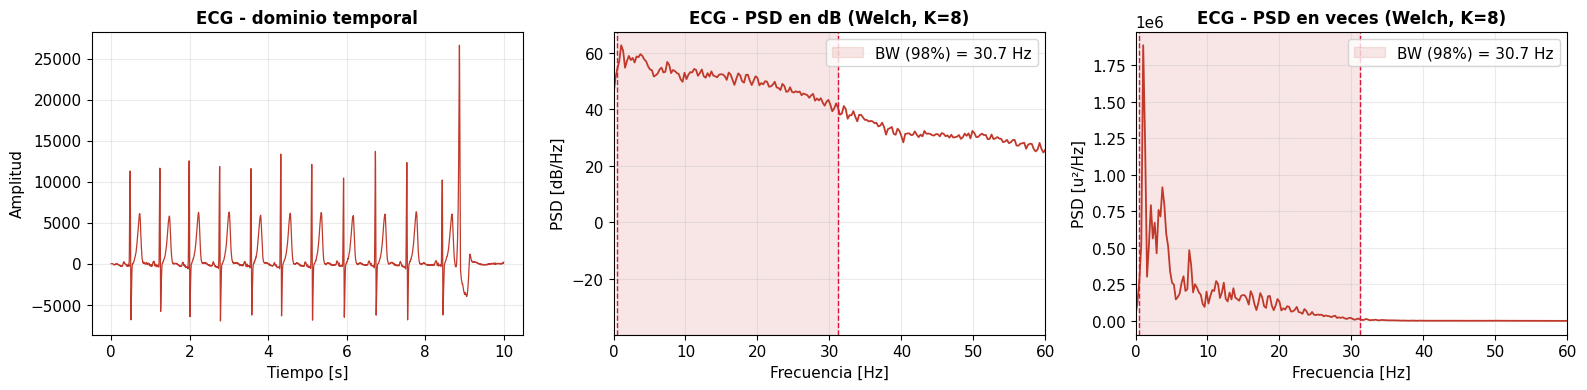

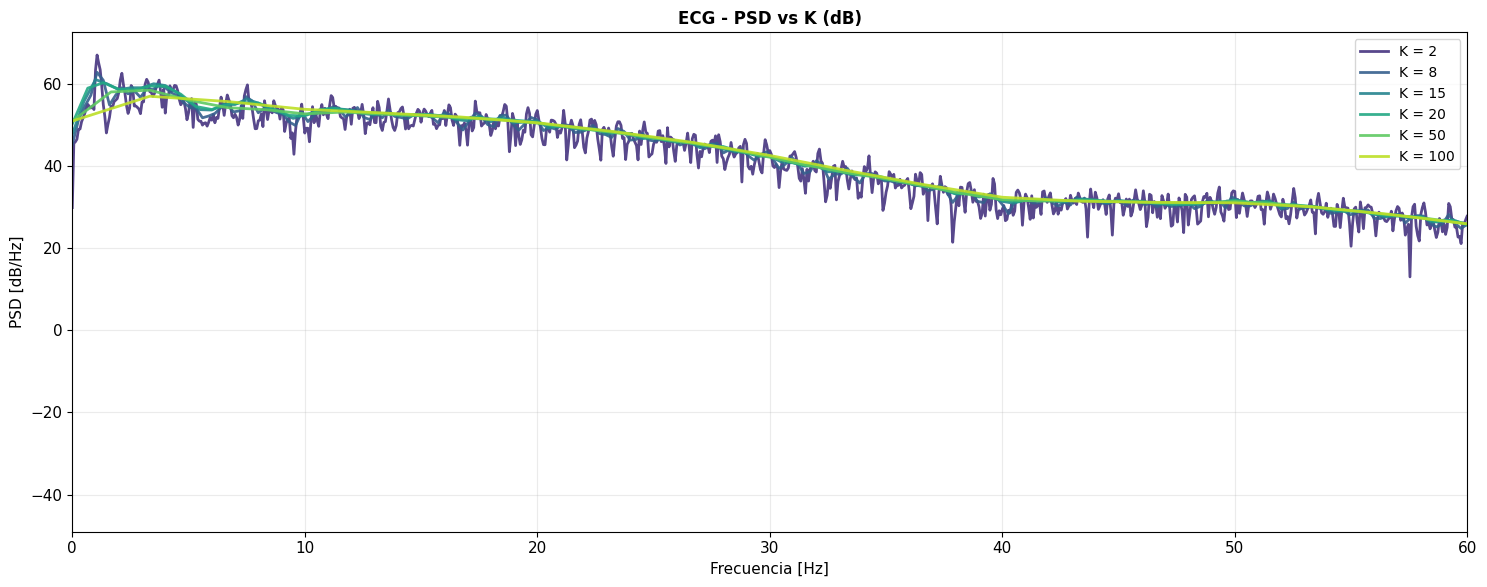

  Banda ocupada (98% de la potencia): 0.53 – 31.20 Hz   ->   BW ≈ 30.7 Hz


In [5]:
fs_ecg = FS_ECG
ecg = np.load("ecg_sin_ruido.npy")

f_ecg, P_ecg, bw_ecg = analizar_senal(ecg, fs_ecg, "ECG",
                              color=COL["ECG"], f_max=60, t_zoom=10, K_list=K_list, pot=POT_BW)

## PPG

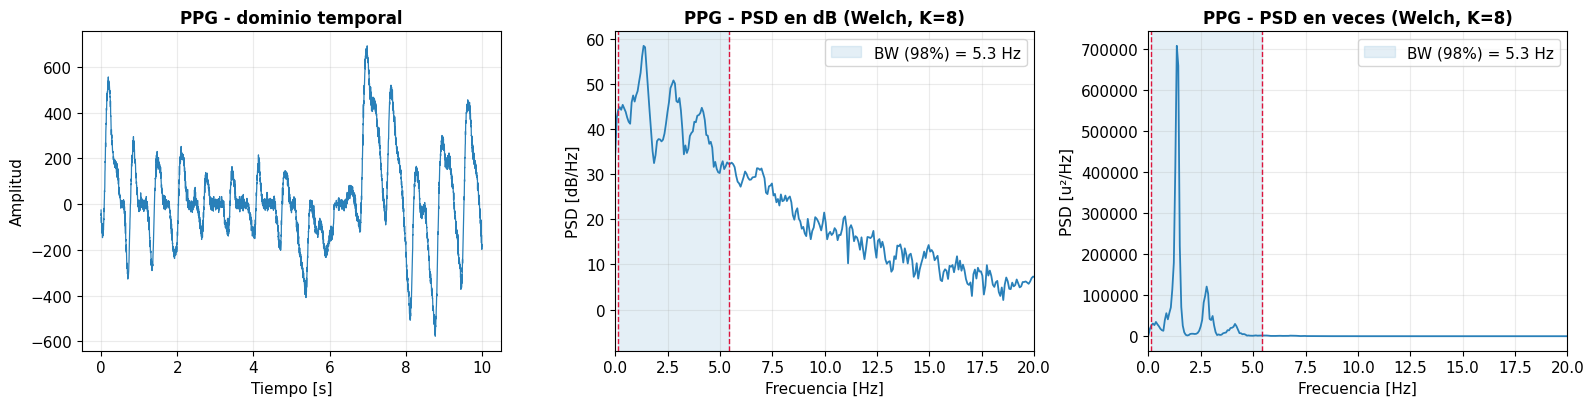

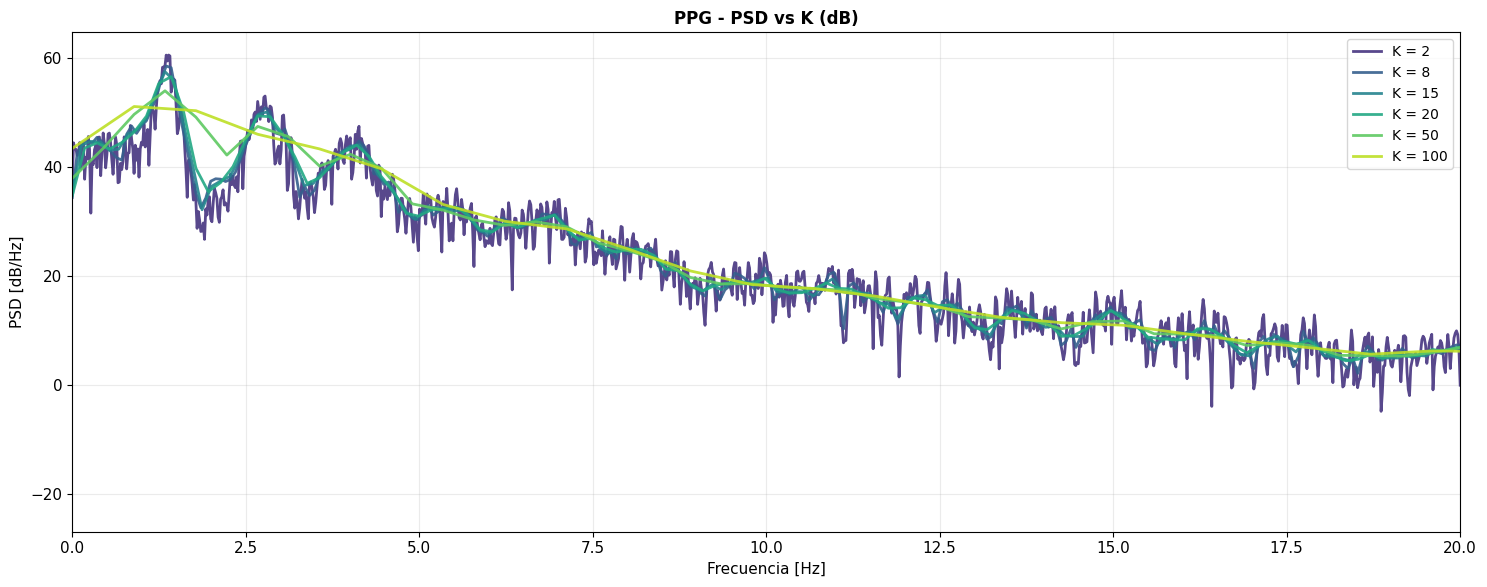

  Banda ocupada (98% de la potencia): 0.14 – 5.42 Hz   ->   BW ≈ 5.3 Hz


In [6]:
fs_ppg = FS_PPG
ppg = np.load("ppg_sin_ruido.npy")

f_ppg, P_ppg, bw_ppg = analizar_senal(ppg, fs_ppg, "PPG",
                              color=COL["PPG"], f_max=20, t_zoom=10, K_list=K_list, pot=POT_BW)

## Audio - Silbido

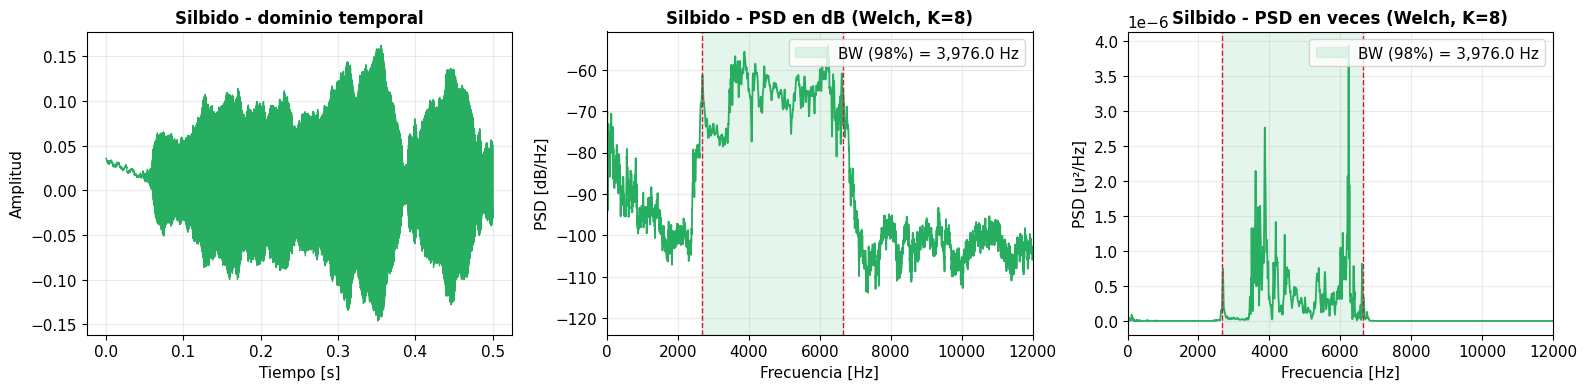

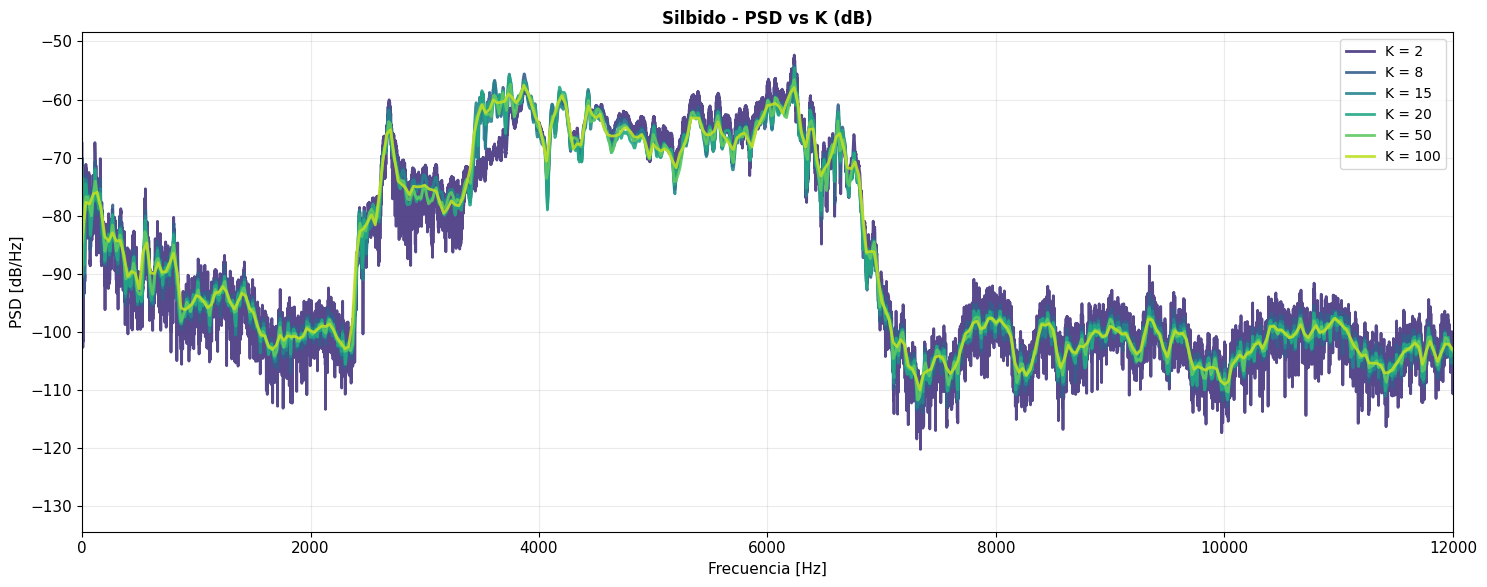

  Banda ocupada (98% de la potencia): 2,674.67 – 6,650.67 Hz   ->   BW ≈ 3,976.0 Hz


In [7]:
fs_sil, silbido = wavfile.read("silbido.wav")

f_sil, P_sil, bw_sil = analizar_senal(silbido, fs_sil, "Silbido",
                              color=COL["Silbido"], f_max=12000, t_zoom=0.5, K_list=K_list, pot=POT_BW)

## Audio - La cucaracha

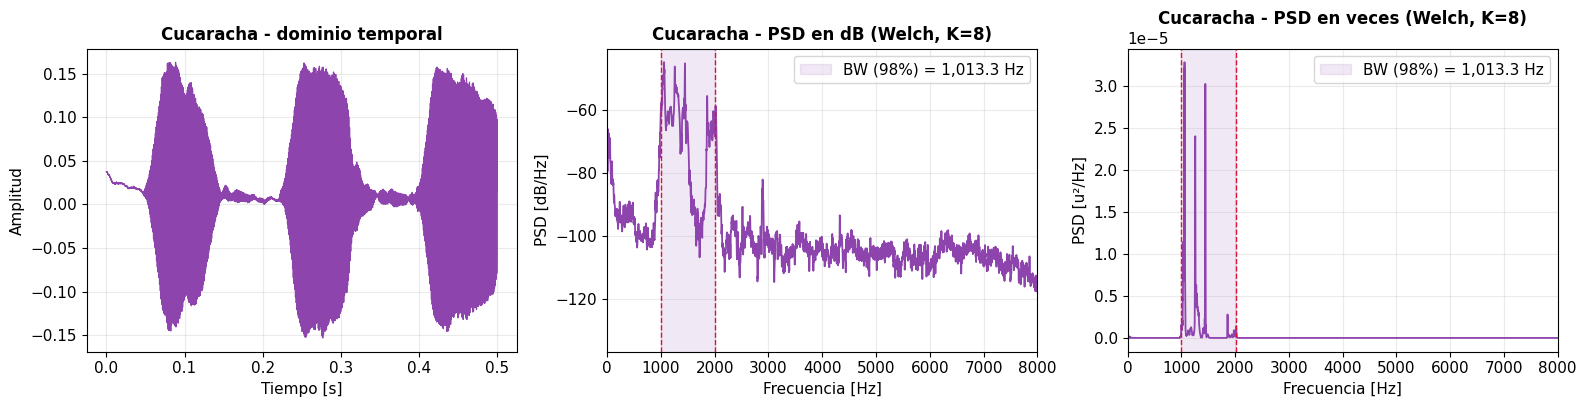

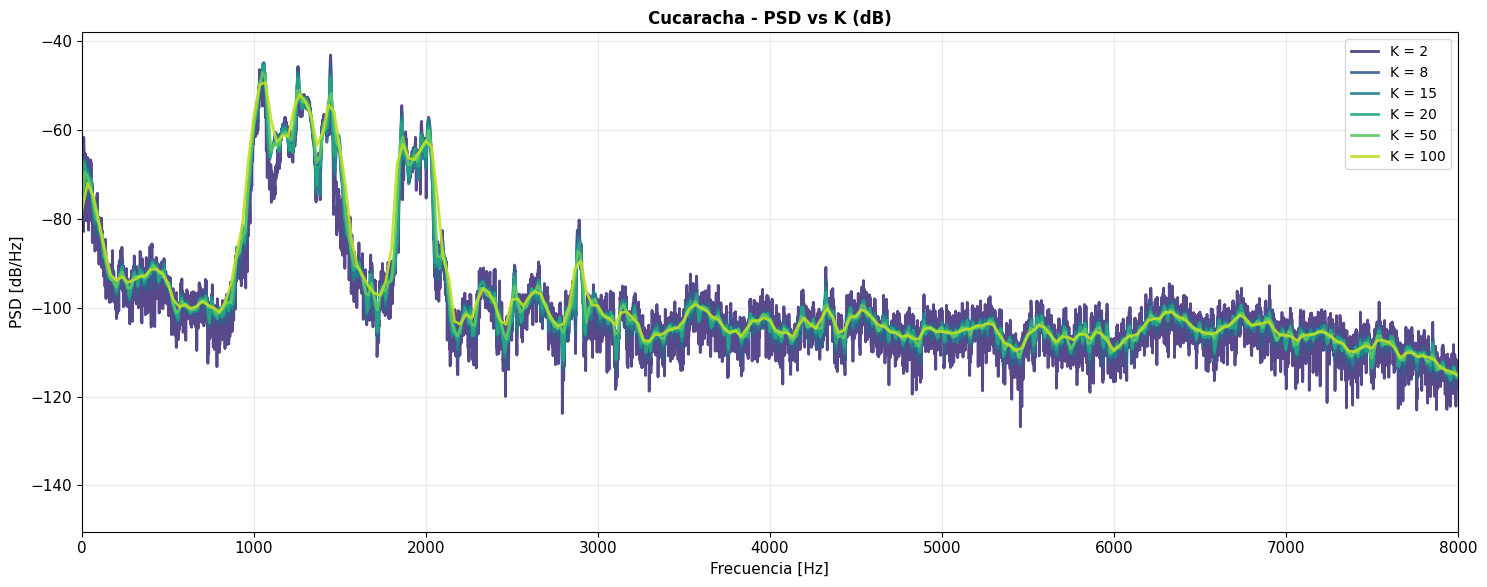

  Banda ocupada (98% de la potencia): 1,000.00 – 2,013.33 Hz   ->   BW ≈ 1,013.3 Hz


In [8]:
fs_cuc, cucaracha = wavfile.read("la cucaracha.wav")

f_cuc, P_cuc, bw_cuc = analizar_senal(cucaracha, fs_cuc, "Cucaracha",
                              color=COL["Cucaracha"], f_max=8000, t_zoom=0.5, K_list=K_list, pot=POT_BW)

# Bonus - Analisis de audios propios


## Extraemos el audiuo a algo legible por python

Uso un audio .mp3 mio cantando "La cucaracha" para analizar. para eso uso "librosa" que es una libreria utilizada para muestrear señales de audio

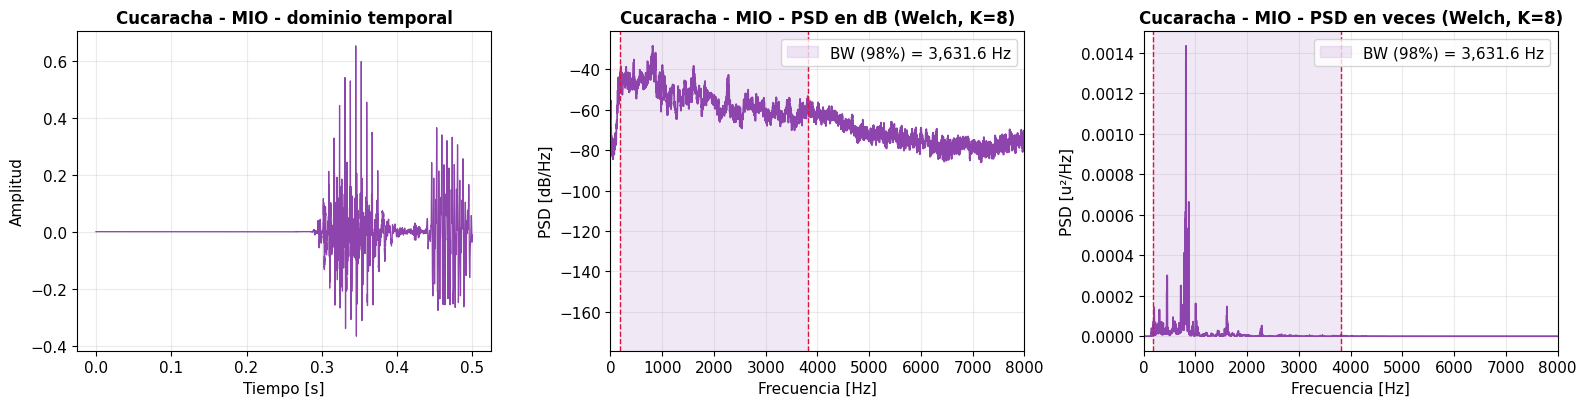

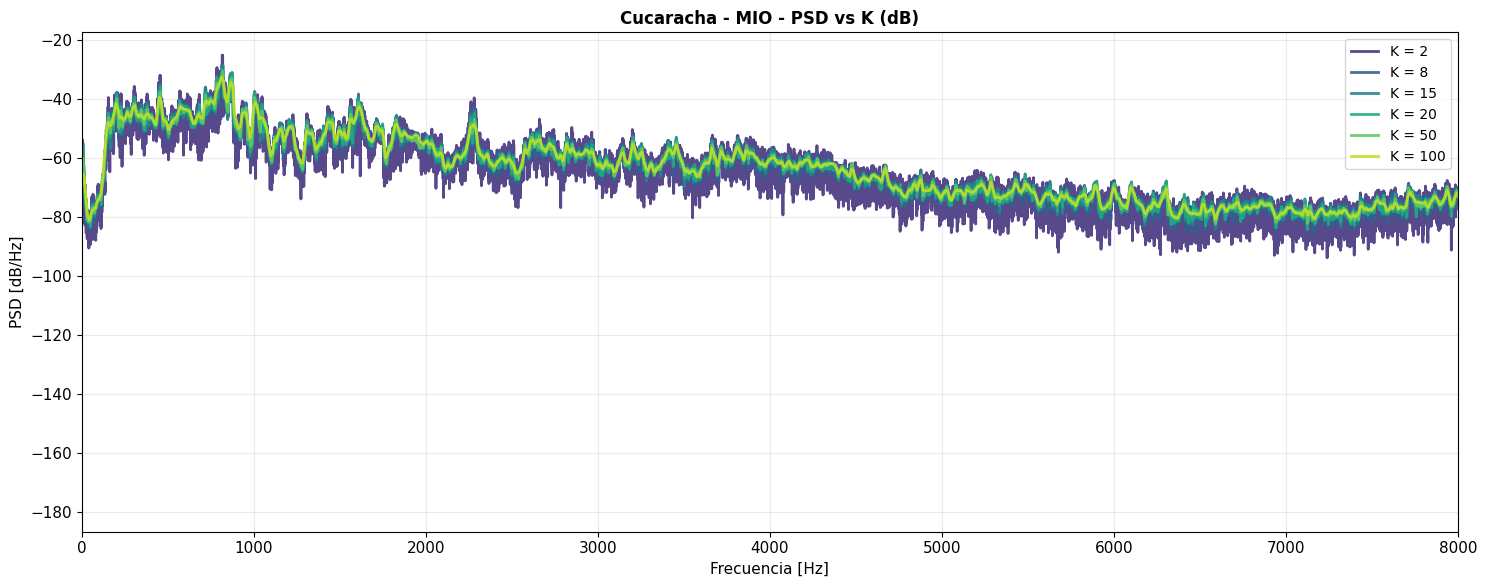

  Banda ocupada (98% de la potencia): 178.95 – 3,810.53 Hz   ->   BW ≈ 3,631.6 Hz


In [9]:
cucaracha_mio, cucaracha_mio_fs = librosa.load("LaCucaracha_MIO.mp3", sr=None)


f_cuc, P_cuc, bw_cuc_mio = analizar_senal(cucaracha_mio, cucaracha_mio_fs, "Cucaracha - MIO", 
                              color=COL["Cucaracha"], f_max=8000, t_zoom=0.5, K_list=K_list, pot=POT_BW)

# Conclusiones
Se ve claramente como en todos los casos, al aumentar el numero de K (segmentos en los que se divide la señal muestreada), la PSD se torna mas suave y estable (desaparece ese "ruido", reduce la varianza del estimador)

Sin embargo, al aumentar DEMASIADO, el valor de K, los segmentos se vuelven mas cortos, y pierden resolucion frecuencial, haciendo que el estimador deje de seguir fielmente a la señal original.

En resumen, lo ideal es tener un valor de K intermedio. que sea un buen compromiso entre un espectro lo suficientemente claro, y un espectro que represente fielmente a la señal original


In [10]:
bws = {
    "ECG":             bw_ecg,
    "PPG":             bw_ppg,
    "Silbido":         bw_sil,
    "Cucaracha":       bw_cuc,
    "Cucaracha - MIO": bw_cuc_mio,
}

print("Anchos de banda estimados (98% de la potencia):")
for nombre, bw in bws.items():
    print(f"  {nombre:<16}: BW = {bw:>10,.1f} Hz")


Anchos de banda estimados (98% de la potencia):
  ECG             : BW =       30.7 Hz
  PPG             : BW =        5.3 Hz
  Silbido         : BW =    3,976.0 Hz
  Cucaracha       : BW =    1,013.3 Hz
  Cucaracha - MIO : BW =    3,631.6 Hz
